In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent))

from amo.constants import *

from general.plot_settings import colors, paper_settings

plt.rcParams.update(paper_settings)
figsize = (4.5, 2.5)

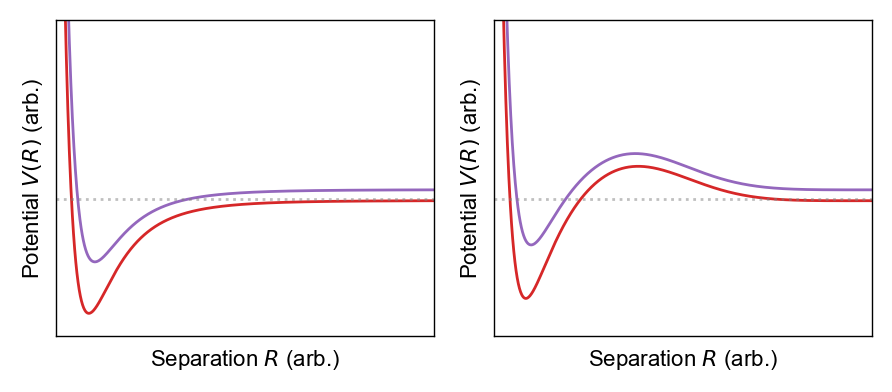

In [41]:
figsize = (4.5, 2)
fig, axs = plt.subplots(1, 2, figsize=figsize)

color = colors[3]

num = 1000
Rmin = 1
Rmax = 4
offset = 0.06

Rs = np.linspace(Rmin, Rmax, num)

def V(R, A=10, a6=0.5, a8=1):
    return A*(-a6/R**6 + a8/R**12)

def Vpwave(R, A=10, a6=0.5, a8=1, a2=0.25):
    R0 = 2.0
    return A*(-a6/R**6 + a8/R**12) + a2 * np.exp(-(R-R0)**2/(2*0.5**2))

# ax = axs[1]
ymin = -0.75
ymax = 1
xlabel = r'Separation $R$ (arb.)'
ylabel = r"Potential $V(R)$ (arb.)"

ax = axs[0]
ax.plot(Rs, V(Rs) , '-', color=colors[3])
ax.plot(Rs, V(Rs, a6=0.4) + offset, '-', color=colors[4])
# ax.vlines(B0_97, ymin, ymax, colors=color, linestyles='--')

ax = axs[1]
ax.plot(Rs, Vpwave(Rs) , '-', color=colors[3])
ax.plot(Rs, Vpwave(Rs, a6=0.4) + offset, '-', color=colors[4])


# Turn off ticks and labels for both axes
for ax in axs:
	ax.tick_params(
		axis='both',          # changes apply to the x and y axes
		which='both',         # both major and minor ticks are affected
		bottom=False,         # ticks along the bottom edge are off
		top=False,            # ticks along the top edge are off
		left=False,           # ticks along the left edge are off
		right=False,          # ticks along the right edge are off
		labelbottom=False,    # labels along the bottom edge are off
		labelleft=False       # labels along the left edge are off
	)
	ax.set(ylabel=ylabel, xlabel=xlabel)
	ax.set(xlim=(Rmin, Rmax), 
	   ylim=(ymin, ymax)
	   )
	ax.hlines(0.01, Rmin, Rmax, colors='gray', linestyles=':', alpha=0.5)

# ax.text(196.5, 0.6, "repulsive", fontsize=8)
# ax.text(195, 0.06, "threshold", color='gray', fontsize=8)
# ax.text(204.5, -0.5, "attractive", fontsize=8)

# ax.text(201.5, 0.1, "unitarity", rotation=90, fontsize=8)


# ax.set_ylim(ymin, ymax)
# ax.legend(loc="upper left", fontsize=7)

# Inset for scattering length near zero crossing
# Bmin = 208
# Bmax = 210
# B = np.linspace(Bmin, Bmax, num)
                
# ax_inset = ax.inset_axes([0.63, 0.63, 0.32, 0.32])
# ax_inset.set(xlim=(Bmin, Bmax))
# ax_inset.hlines(0, Bmin, Bmax, colors='gray', linestyles='--', alpha=0.5)
# ax_inset.plot(B, a97(B)/a_0/1e3 , '-', color=color)

# ax_inset.set_xticks([208, 209, 210])
# ax_inset.set_xticklabels(["208", "209", "210"])

# ax.indicate_inset_zoom(ax_inset, edgecolor="black")
# ax_inset.text(209, -0.02, "   zero\ncrossing", fontsize=8)

# # Binding energy inset
# Bmin = 200
# Bmax = 202.14
# B = np.linspace(Bmin, Bmax, num)  # G

# ax_inset2 = ax.inset_axes([0.15, 0.12, 0.32, 0.35])

# ymax = 40
# ymin = np.min(Eb_s97(B)/1e3/h)

# ylabel = r"$E_B$ (kHz)"
# ax_inset2.set(ylabel=ylabel, xlim=(Bmin, 202.5), ylim=(ymin, ymax))
# ax_inset2.hlines(0, Bmin, 202.5, colors='gray', linestyles='--', alpha=0.5)
# # ax.set_box_aspect(0.8)

# ax_inset2.plot(B, Eb_s97(B)/1e3/h, '-', label=r"$M_L=\pm 1$", color='k')
# ax_inset2.vlines(B0_97, ymin, ymax, colors=color, linestyles='--')
# ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()  # Note this is done before the labels on purpose.

# axs = [ax, ax_inset, ax_inset2]
# subplot_labels = ['(a)', '(b)', '(c)']
# positions = [(-0.14, 0.98), (0.05, 0.8), (0.05, 0.82)]
# for ax, label, xy in zip(axs, subplot_labels, positions):
# 	x, y = xy
# 	ax.text(x, y, label, transform=ax.transAxes, fontweight='bold', fontsize=8)
	
# plt.subplots_adjust(top=0.95)

# fig.savefig("outputs/swave_scattering_parameters.pdf")

plt.show()